------------DAY-7-----------

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder ,  StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score , accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, roc_auc_score , auc
from sklearn.ensemble import RandomForestClassifier
import warnings 
warnings.filterwarnings("ignore")

PROGRAM-1

AUC Score: 0.99737962659679


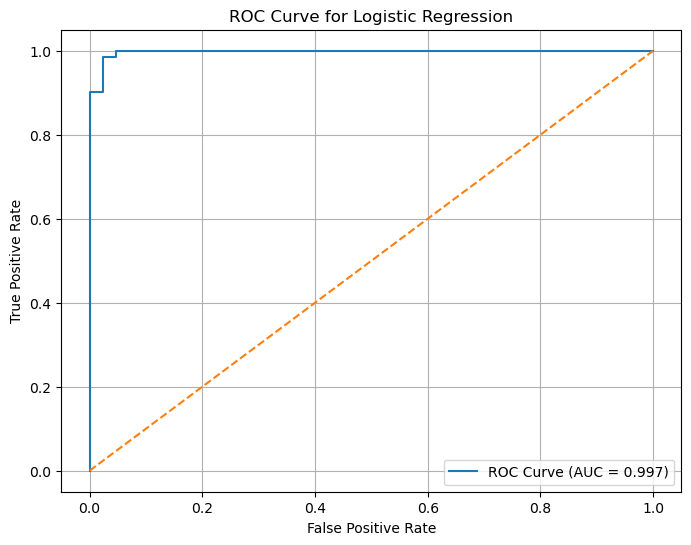

In [2]:
#Plot ROC curve and calculate AUC for Logistic Regression 
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve, roc_auc_score , auc

# Load dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

PROGRAM-2

In [3]:
# Use GridSearchCV to tune Random Forest hyperparameters 
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

# Define Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]          }

# Apply Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best cross-validation score
print("\nBest CV Accuracy : " , (grid_search.best_score_))

# Best model
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred = best_rf.predict(X_test)

# Test accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy : " , (accuracy ))

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Accuracy :  0.9626373626373625

Test Accuracy :  0.9649122807017544


PROGRAM-3

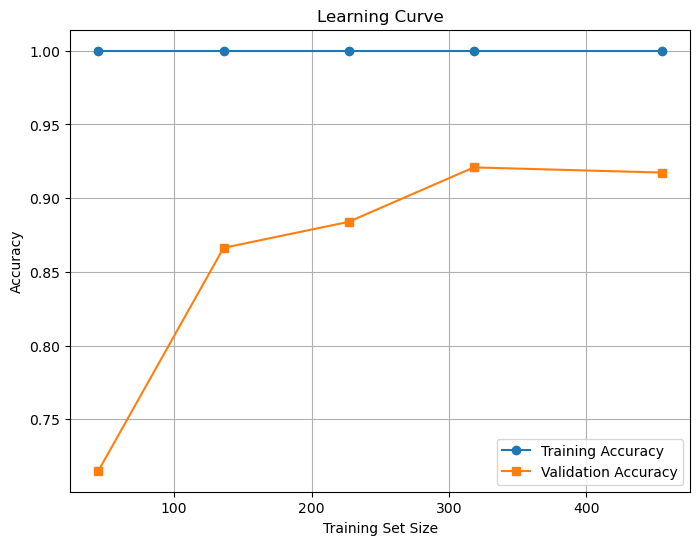

In [4]:
# Plot learning curves to diagnose bias/variance 
from sklearn.model_selection import learning_curve

# Load dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Model
model = DecisionTreeClassifier(random_state=42)

# Generate learning curves
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    scoring='accuracy',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    random_state=42                             )

# Calculate mean scores
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Accuracy'            )
plt.plot(
    train_sizes,
    validation_mean,
    marker='s',
    label='Validation Accuracy'           )
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

PROGRAM-4

In [ ]:
#Build a metrics comparison table for 3 models on the same dataset 
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Store results
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Convert to percentage
results_df.iloc[:,1:] = results_df.iloc[:,1:] * 100
print(results_df.round(2))

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     97.37      97.22   98.59     97.90
1                  KNN     94.74      95.77   95.77     95.77
2        Random Forest     96.49      95.89   98.59     97.22


--------PRACTICE SHEET----------

PROGRAM-5

In [6]:
# Full model comparison pipeline: train 5 models, rank by F1 
# Import libraries
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42 , stratify=y)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

# Store results
results = []

# Train and evaluate models
for name, model in models.items():

    # Pipeline for scaling + model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Store metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Convert to percentages
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    results_df[col] = results_df[col] * 100

# Rank by F1-Score
results_df = results_df.sort_values(by='F1-Score' , ascending=False).reset_index(drop=True)

# Add ranking column
results_df.insert(0, 'Rank', range(1, len(results_df)+1))

# Display results
print(results_df.round(2))

   Rank                Model  Accuracy  Precision  Recall  F1-Score
0     1  Logistic Regression     98.25      98.61   98.61     98.61
1     2                  SVM     98.25      98.61   98.61     98.61
2     3                  KNN     95.61      95.89   97.22     96.55
3     4        Random Forest     95.61      95.89   97.22     96.55
4     5        Decision Tree     91.23      95.59   90.28     92.86


PROGRAM-6

In [7]:
#Tune SVM with GridSearchCV and report best parameters 
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42 , stratify=y)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Hyperparameter grid
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters : " , (grid_search.best_params_))

# Best cross-validation score
print("\nBest CV F1 Score : " , (round(grid_search.best_score_, 4)))

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Test accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy : " , (round(accuracy, 4)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Parameters :  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Best CV F1 Score :  0.9844

Test Accuracy :  0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

